## Data Visualization Practice

### Case Study: E-commerce Sales Performance Analysis

#### Business Problem
An e-commerce company wants to understand:
- Monthly sales trend
- Category-wise revenue contribution
- Regional performance
- Top-performing products
- Relationship between discount and sales

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

#### Dataset

In [2]:
data = {
    'Order_Date': ['2025-01-10','2025-01-15','2025-02-05','2025-02-18',
                   '2025-03-10','2025-03-22','2025-04-05','2025-04-18',
                   '2025-05-12','2025-05-25'],

    'Category': ['Electronics','Furniture','Electronics','Clothing',
                 'Furniture','Electronics','Clothing','Furniture',
                 'Electronics','Clothing'],

    'Region': ['North','South','East','West',
               'North','South','East','West',
               'North','South'],

    'Product': ['Laptop','Chair','Mobile','T-Shirt',
                'Table','Laptop','Jeans','Sofa',
                'Mobile','Jacket'],

    'Sales': [1200,400,800,150,600,1300,200,900,850,300],

    'Discount': [5,10,8,15,12,5,20,10,7,18]
}

In [3]:
df = pd.DataFrame(data)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Order_Date  10 non-null     object
 1   Category    10 non-null     object
 2   Region      10 non-null     object
 3   Product     10 non-null     object
 4   Sales       10 non-null     int64 
 5   Discount    10 non-null     int64 
dtypes: int64(2), object(4)
memory usage: 612.0+ bytes


In [5]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [6]:
df.head()

,Order_Date,Category,Region,Product,Sales,Discount
0,2025-01-10,Electronics,North,Laptop,1200,5
1,2025-01-15,Furniture,South,Chair,400,10
2,2025-02-05,Electronics,East,Mobile,800,8
3,2025-02-18,Clothing,West,T-Shirt,150,15
4,2025-03-10,Furniture,North,Table,600,12


# 

### 1: Monthly Sales Trend
How is revenue changing month-over-month?

In [7]:
df['Month'] = df['Order_Date'].dt.month_name()

In [8]:
df.head()

,Order_Date,Category,Region,Product,Sales,Discount,Month
0,2025-01-10,Electronics,North,Laptop,1200,5,January
1,2025-01-15,Furniture,South,Chair,400,10,January
2,2025-02-05,Electronics,East,Mobile,800,8,February
3,2025-02-18,Clothing,West,T-Shirt,150,15,February
4,2025-03-10,Furniture,North,Table,600,12,March


In [9]:
monthly_sales = (df.groupby('Month')['Sales'].sum().reset_index())

In [10]:
monthly_sales

,Month,Sales
0,April,1100
1,February,950
2,January,1600
3,March,1900
4,May,1150


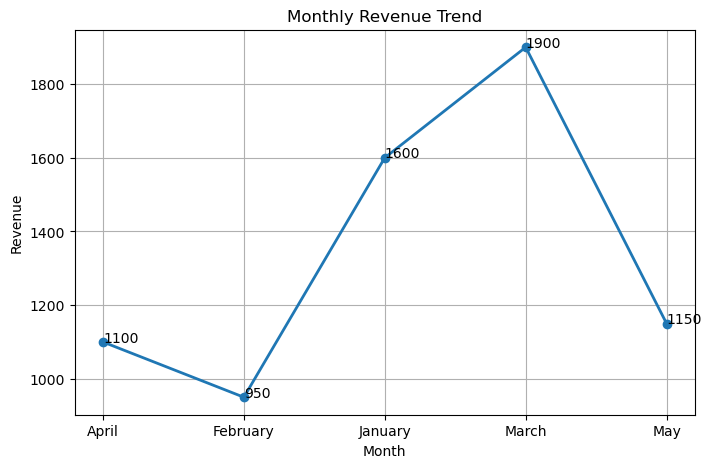

In [18]:
plt.figure(figsize=(8,5))
plt.plot(monthly_sales['Month'],monthly_sales['Sales'],marker='o',linewidth=2)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
for i, value in enumerate(monthly_sales['Sales']):
    plt.annotate(value, xy=(i, value))
plt.show()

- March generated highest revenue.
- In February significant drop.
- Revenue recovered after February.

# 

# 

#### 2: Category Revenue Analysis
Which category contributes the most revenue?

In [20]:
category_sales = df.groupby('Category')['Sales'].sum().reset_index()

In [21]:
category_sales

,Category,Sales
0,Clothing,650
1,Electronics,4150
2,Furniture,1900


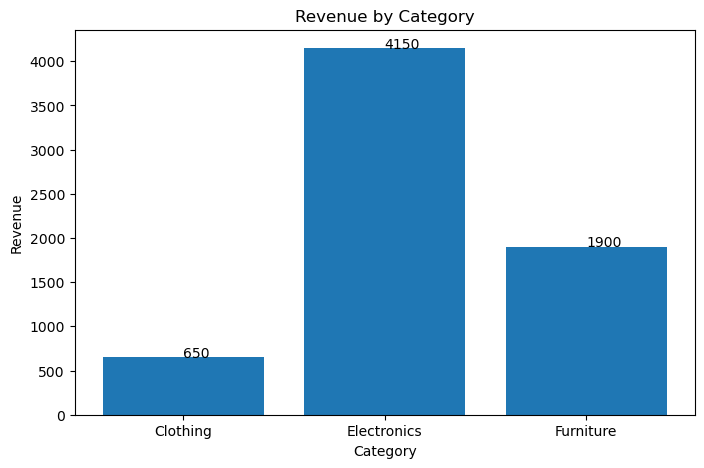

In [24]:
plt.figure(figsize=(8,5))
plt.bar(category_sales['Category'], category_sales['Sales'])
plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
for i, va in enumerate(category_sales['Sales']):
    plt.annotate(va, xy=(i,va))

plt.show()

###### Insight

-  Electronics category generates  the most revenue

# 

#### 3: Regional Performance
Which region generates the most revenue?

In [37]:
region_sales = df.groupby('Region')['Sales'].sum().reset_index()

In [38]:
region_sales

,Region,Sales
0,East,1000
1,North,2650
2,South,2000
3,West,1050


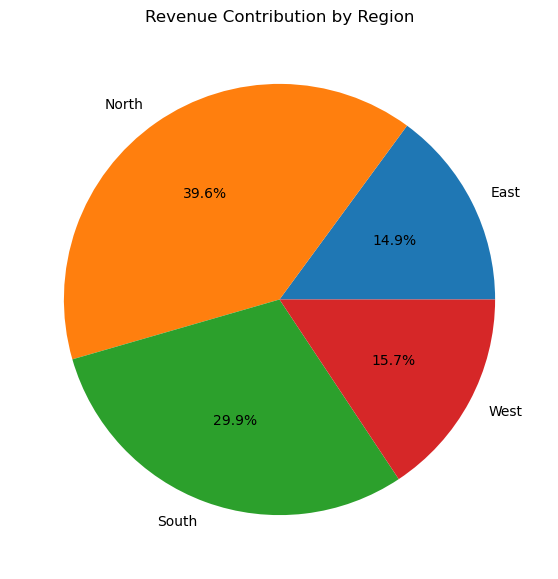

In [49]:
plt.figure(figsize=(7,7))
plt.pie(region_sales['Sales'],labels=region_sales['Region'],autopct='%1.1f%%')
plt.title('Revenue Contribution by Region')
plt.show()

- South region contributes the largest share.

# 

# 

#### 4: Top Products Analysis
Which products drive revenue?

In [50]:
product_sales = (df.groupby('Product')['Sales'].sum().sort_values(ascending=False).reset_index())

In [51]:
product_sales

,Product,Sales
0,Laptop,2500
1,Mobile,1650
2,Sofa,900
3,Table,600
4,Chair,400
5,Jacket,300
6,Jeans,200
7,T-Shirt,150


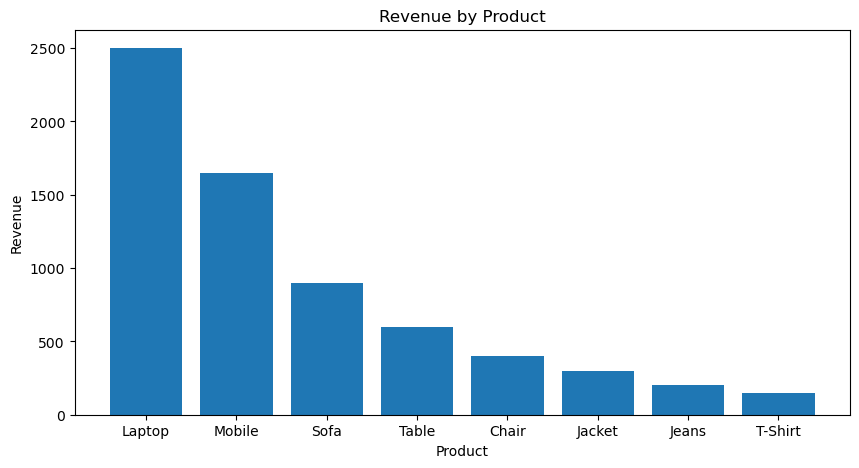

In [67]:
plt.figure(figsize=(10,5))
plt.bar(product_sales['Product'], product_sales['Sales'])
plt.title('Revenue by Product')
plt.ylabel('Revenue')
plt.xlabel('Product')
plt.show()

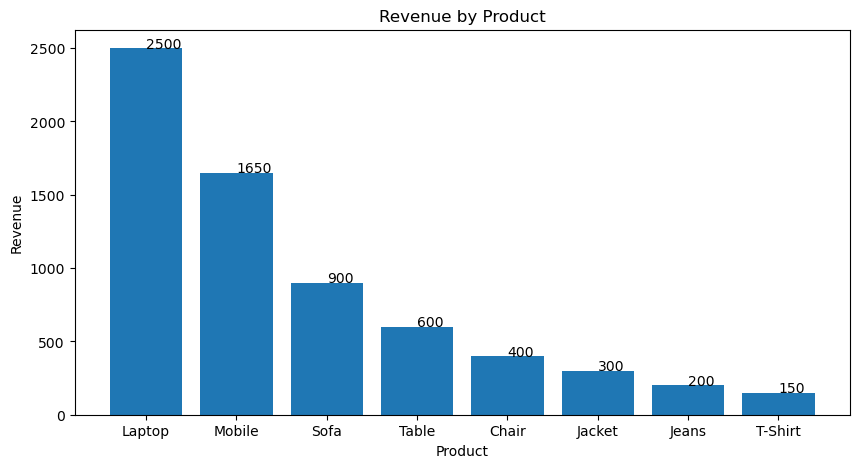

In [68]:
plt.figure(figsize=(10,5))
plt.bar(product_sales['Product'], product_sales['Sales'])
plt.title('Revenue by Product')
plt.ylabel('Revenue')
plt.xlabel('Product')
for i, val in enumerate(product_sales['Sales']):
    plt.annotate(val, xy=(i,val))
plt.show()

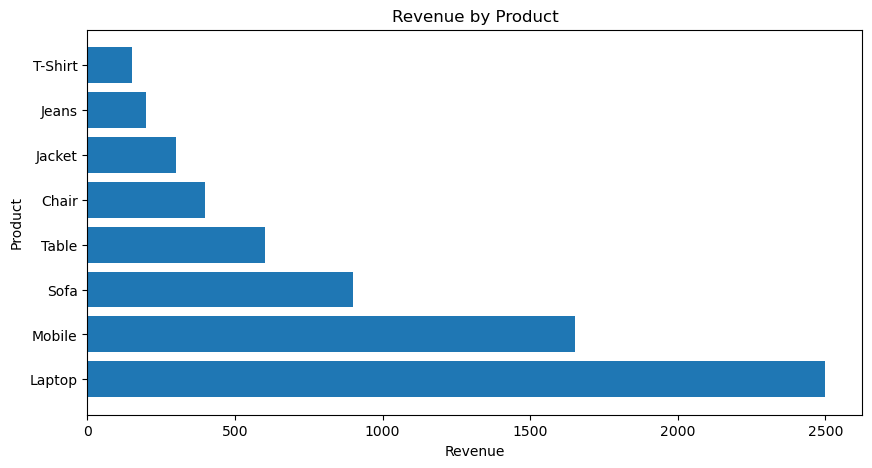

In [69]:
plt.figure(figsize=(10,5))
plt.barh(product_sales['Product'], product_sales['Sales'])
plt.title('Revenue by Product')
plt.xlabel('Revenue')
plt.ylabel('Product')
for i, val in enumerate(product_sales['Sales']):
    plt.annotate(val, xy=(i,val))
plt.show()

# 

# 

#### 5: Discount vs Sales Analysis
Do higher discounts generate higher sales?

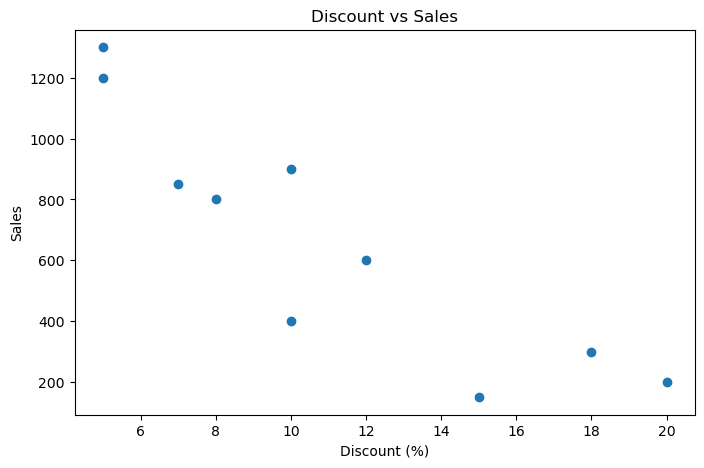

In [72]:
plt.figure(figsize=(8,5))
plt.scatter(df['Discount'],df['Sales'])
plt.title('Discount vs Sales')
plt.xlabel('Discount (%)')
plt.ylabel('Sales')

plt.show()

- High sales often occur with low discounts.
- Large discounts do not necessarily increase revenue.